# Numerical calculation

Steady-state intensity = 1.2731821344584695
g2(0) = 0.7733499850232952


/home/kawai/anaconda3/envs/qutip/lib/python3.14/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


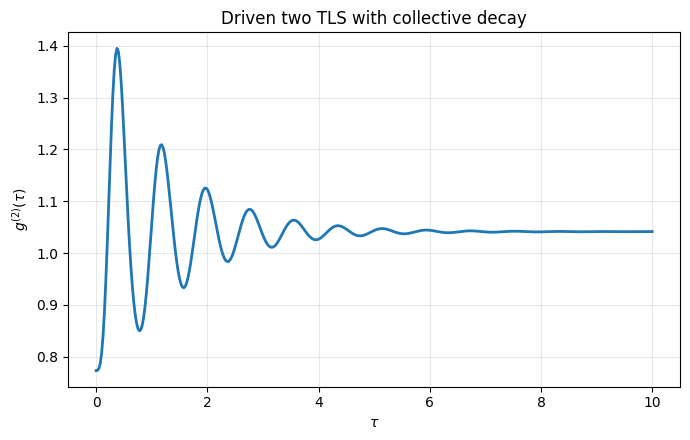

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# ==========================================
# Parameters
# ==========================================
Gamma = 1.0          # single-emitter spontaneous decay rate
Gamma12 = 1.0        # collective decay
Omega12 = 0.5        # coherent dipole-dipole exchange coupling
Omega_R = 8.0       # external driving Rabi frequency
Delta = 0.0          # detuning: Delta = omega_L - omega_0
gamma_phi = 0.0      # optional pure dephasing per emitter

taulist = np.linspace(0, 10, 400)

# ==========================================
# Operators
# ==========================================
si = qeye(2)
sm = destroy(2)
sp = sm.dag()
sx = sigmax()
sz = sigmaz()

sm1 = tensor(sm, si)
sm2 = tensor(si, sm)
sp1 = sm1.dag()
sp2 = sm2.dag()
sx1 = tensor(sx, si)
sx2 = tensor(si, sx)
sz1 = tensor(sz, si)
sz2 = tensor(si, sz)

# ==========================================
# Hamiltonian in rotating frame
# ==========================================
# H0        = -Delta * sum_i sigma_i^+ sigma_i^-
# H_dd      = Omega12 * (sigma_1^+ sigma_2^- + sigma_2^+ sigma_1^-)
# H_drive   = (Omega_R/2) * sum_i (sigma_i^+ + sigma_i^-)
#
# with hbar = 1

H0 = -Delta * (sp1 * sm1 + sp2 * sm2)
Hdd = Omega12 * (sp1 * sm2 + sp2 * sm1)
Hdrive = 0.5 * Omega_R * ((sp1 + sm1) + (sp2 + sm2))

H = H0 + Hdd + Hdrive

# ==========================================
# Full collective-decay Liouvillian
# ==========================================
Gamma_mat = np.array([[Gamma,   Gamma12],
                      [Gamma12, Gamma  ]], dtype=float)

sm_ops = [sm1, sm2]
sp_ops = [sp1, sp2]

L = liouvillian(H, [])

for i in range(2):
    for j in range(2):
        gij = Gamma_mat[i, j]
        if abs(gij) > 1e-15:
            A = sm_ops[j]   # sigma_j^-
            B = sp_ops[i]   # sigma_i^+
            L += 0.5 * gij * (
                2 * spre(A) * spost(B)
                - spre(B * A)
                - spost(B * A)
            )

# Optional pure dephasing
if gamma_phi > 0:
    L += liouvillian(None, [np.sqrt(gamma_phi / 2.0) * sz1,
                            np.sqrt(gamma_phi / 2.0) * sz2])

# ==========================================
# Steady state
# ==========================================
rho_ss = steadystate(L)

# ==========================================
# Detection operator
# ==========================================
# Symmetric detection direction
J_det = sm1 + sm2

n_op = J_det.dag() * J_det
I_ss = expect(n_op, rho_ss)

if I_ss <= 1e-14:
    raise ValueError("Steady-state intensity too small; g2 is ill-defined.")

# ==========================================
# Conditional state after one detection
# ==========================================
rho_cond = J_det * rho_ss * J_det.dag()
rho_cond = rho_cond / rho_cond.tr()

# ==========================================
# Evolve conditional state
# ==========================================
result = mesolve(L, rho_cond, taulist, [], [n_op])
I_cond = np.array(result.expect[0])

g2 = I_cond / I_ss

# ==========================================
# Output
# ==========================================
print("Steady-state intensity =", I_ss)
print("g2(0) =", g2[0])

# ==========================================
# Plot
# ==========================================
plt.figure(figsize=(7, 4.5))
plt.plot(taulist, g2, lw=2)
plt.xlabel(r'$\tau$')
plt.ylabel(r'$g^{(2)}(\tau)$')
plt.title(r'Driven two TLS with collective decay')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()